# Kohn-Sham inversion calculations

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  26/03/2024  
**Last modified:**  25/08/2025

## 1. Introduction

In this tutorial, I will present examples of Kohn-Sham (KS) inversion calculations using Molpro. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting potentials and densities, accessing eigenvalues, density errors, etc. The tutorial is written in Jupyter Notebook. Therefore, I will use Python as a high-level programming language for preparing input files and processing of outputs.  
This tutorial complements the documentation of the KS inversion code in the Molpro manual, which I recommend you read first. I do not describe all possible input options and/or keywords, but concentrate on practical examples.

---

For a short but great overview of inverse KS methods, I recommend reading the following article:  
> Y. Shi, A. Wasserman, Inverse Kohn–Sham density functional theory: progress and challenges – J. Phys. Chem. Lett. 12, 22 (2021) 5308-5318. [link](https://doi.org/10.1021/acs.jpclett.1c00752)

The Molpro implementation of KS inversion follows the so-called response function approach proposed in:
> A. Görling, Kohn-Sham potentials and wave functions from electron densities – Phys. Rev. A 46 (1992) 3753. [link](https://link.aps.org/doi/10.1103/PhysRevA.46.3753)

The actual implementation is described in the following publications:
> J. Erhard, E. Trushin, A. Görling, Numerically stable inversion approach to construct Kohn-Sham potentials for given electron densities within a Gaussian basis set framework – J. Chem. Phys. 156 (2022) 204124. [link](https://doi.org/10.1063/5.0087356)  
> J. Erhard, E. Trushin, A. Görling, Kohn-Sham inversion for open-shell systems within the response function approach – J. Chem. Phys. 162, 034116 (2025). [link](https://doi.org/10.1063/5.0239422)  
> S. Fauser, E. Trushin, A. Görling, Highly precise values for the energy ratios underlying the Lieb–Oxford bound and the convexity conjecture for the adiabatic connection – J. Chem. Phys. 162, 164108 (2025). [link](https://doi.org/10.1063/5.0263582) 

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

Kohn-Sham inversion calculations requires to specify two basis sets, namely orbital and OEP basis sets. If density fitting is employed, the corresponding basis sets have to be also specified. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange-correlation potential. 
Gaussian basis set KS inversion methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets.
Present implementation of KS inversion in Molpro use a preprocessing of the auxiliary basis set that enables such balancing in an automatic fashion for standard Gaussian basis sets.
The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  |  5e-2   |
| aug-cc-pwCVQZ  | 1.7e-2  |
| aug-cc-pwCV5Z  |  5e-3   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X=T,Q,5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

---

There are two drivers in Molpro to perform KS inversion: `ksinv` and `uksinv`. `ksinv` uses one set of spatial orbitals and is designed to perform either inversion for closed-shell systems or spin-restricted KS inversion for open-shell systems. `uksinv` uses two different sets of spatial orbitals for $\alpha$ and $\beta$ electrons and performs spin-unrestricted KS inversion.

---

Let's start with the import of the required libraries.

In [1]:
# Standard libraries
import os
import shutil
import pandas as pd
import numpy as np

# Imports for plotting
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

The examples in this tutorial are designed to avoid computationally demanding calculations. I use my laptop for all the calculations.  
We can check information about my CPUs.

In [2]:
!lscpu | head -n 12

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           48 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  16
On-line CPU(s) list:                     0-15
Vendor ID:                               AuthenticAMD
Model name:                              AMD Ryzen 9 5900HX with Radeon Graphics
CPU family:                              25
Model:                                   80
Thread(s) per core:                      2
Core(s) per socket:                      8


I have Molpro in the directory `/home/trushin/Molpro/molpro`, and I am going to run it with the options `-m 2000 --no-xml-output`. I will store this in a variable for future use.

In [3]:
MOLPRO = "OMP_THREAD_LIMIT=16 /home/trushin/Molpro/molpro/bin/molpro -m 2000 --no-xml-output"

For the future, I will save the directory where this Jupyter Notebook is located.

In [4]:
NOTEBOOK_DIR = os.getcwd()

## 2. Kohn-Sham inversion for closed-shell systems
In the closed-shell case, the KS inversion determines the KS potential $v_s$ for a given target or reference density $\rho_{ref}$. Note that I use the terms target density and reference density interchangeably throughout the tutorial.  
KS potential $v_s$ is the sum of the external potential of the physical electron system $v_{ext}$, here the electrostatic potential of the nuclei, the Hartree potential $v_H$, the classical electrostatic potential of the electron density $\rho_{ref}$, and the exchange-correlation potential $v_{xc}$.
$$v_s = v_{ext} + v_H + v_{xc}$$
Since $v_{ext}$ and $v_H$ are known, the KS inversion essentially determines the exchange-correlation potential $v_{xc}$, which we will plot/analyze instead of $v_s$.

### 2.1 Kohn-Sham inversion for H$_2$ molecule using CCSD(T) density

We start with the KS inversion of the closed-shell molecule, H$_2$, using the target density from the CCSD(T) calculation. We will plot the resulting exchange, correlation, and exchange-correlation potentials along the bond axis.  
Let's create the directory for this calculation and then go to that directory.

In [5]:
os.makedirs("Tutorials/KSINV/h2_from_ccsdt", exist_ok=True)
os.chdir("Tutorials/KSINV/h2_from_ccsdt/")

Now we write input in file h2.in

In [6]:
%%writefile h2.in
basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
}

symmetry,nosym ! KSINV does not use symmetry

angstrom
geometry={
2

H 0.0 0.0 0.370946
H 0.0 0.0 -0.370946
}

hf,maxit=30 ! HF calculation

{CCSD(T);core;dm,1325.1} ! reference CCSD(T) calculation
e_ref_ccsdt=energy ! save energy to provide as a reference energy to KSINV

! Save relaxed density to the first record - required by KSINV
{matrop;load,den,den,1325.1;save,den,1325.1}

acfd;ksinv,refden=1325.1,e_ref=e_ref_ccsdt,thr_fai_oep=1.7d-2,\
plot_vx=1,plot_vc=1,plot_vxc=1,plot_vref=1,plot_z=1

Writing h2.in


Let's run Molpro calculation.

In [7]:
_ = os.system(f"{MOLPRO} < h2.in > h2.out") # run calculation

Now we can plot resulting potentials.  
The exchange-correlation potential consists of a reference exchange potential $v_x^{ref}$ and a remainder $v_{\bar{x}c}$:
$$v_{xc}=v_x^{ref}+v_{\bar{x}c}$$
We also have access to the individual part of the reminder $v_{\bar{x}c}$, namely a reminder of the exchange potential $v_{\bar{x}}$ and the correlation potential $v_c$.
The correlation potential $v_c$ can be plotted as it is. The exchange potential is the sum of the reference exchange potential $v_x^{ref}$ and the corresponding reminder $v_{\bar{x}}$:
$$v_x=v_x^{ref}+v_{\bar{x}}$$

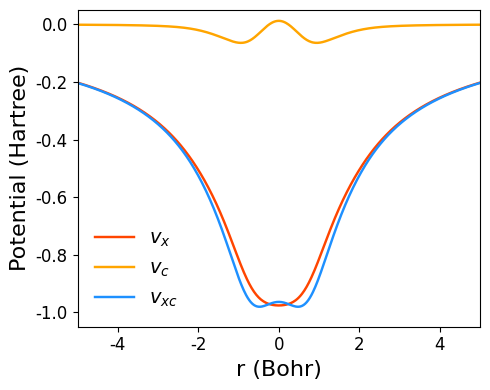

In [8]:
# Read potentials from csv-files
vref = pd.read_csv('vref-total-final-z.csv')
vx = pd.read_csv('vx-total-final-z.csv')
vc = pd.read_csv('vc-total-final-z.csv')
vxc = pd.read_csv('vxc-total-final-z.csv')

# Plot potentials
plt.plot(vx.z, vref.value+vx.value, color='orangered', label='$v_x$')
plt.plot(vc.z, vc.value, color='orange', label='$v_c$')
plt.plot(vxc.z, vref.value+vxc.value, color='dodgerblue', label='$v_{xc}$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.ylim(-1.05, 0.05)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

The resulting exchange-correlation potential looks similar to those calculated with other KS inversion methods, see e.g.
> O.V. Gritsenko and E.J. Baerends, Effect of molecular dissociation on the exchange-correlation Kohn-Sham potential – Phys. Rev. A 54, 1957 (1996). [link](https://doi.org/10.1103/PhysRevA.54.1957)  
> B. Kanungo, P.M. Zimmerman, V. Gavini, Exact exchange-correlation potentials from ground-state electron densities – Nat. Commun. 10, 4497 (2019). [link](https://doi.org/10.1038/s41467-019-12467-0)

### 2.2 Kohn-Sham inversion for H$_2$ molecule using CCSD(T) density, 2 stage calculation with saving density in a file

Since the calculation of the target density can be computationally expensive, it may be useful to separate the calculation of the target density from the actual KS inversion. In this example, we will split the previous calculation for H$_2$ into two steps.

In [9]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/h2_from_ccsdt_2stage", exist_ok=True)
os.chdir("Tutorials/KSINV/h2_from_ccsdt_2stage/")

Let's create an input file for CCSD(T) that stores the density in a file.

In [10]:
%%writefile h2_ccsdt.in
basis={
default,aug-cc-pwCVQZ ! orbital basis
}

symmetry,nosym ! KSINV does not use symmetry

angstrom
geometry={
2

H 0.0 0.0 0.370946
H 0.0 0.0 -0.370946
}

hf,maxit=30 ! HF calculation

{CCSD(T);core;dm,1325.1} ! reference CCSD(T) calculation
{matrop;load,den,den,1325.1;write,den,dm.dat,status=rewind,prec=sci} ! save density to file

Writing h2_ccsdt.in


Let's run CCSD(T) calculation.

In [11]:
_ = os.system(f"{MOLPRO} < h2_ccsdt.in > h2_ccsdt.out") # run calculation

We can get CCSD(T) total energy from the output file to provide as input reference energy to KS inversion.

In [12]:
!grep "!CCSD(T) total energy" h2_ccsdt.out

 !CCSD(T) total energy                 -1.173867500644


Now we can start the KS inversion calculation that reads the stored density.

In [13]:
%%writefile h2_ksinv.in
basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
}

symmetry,nosym ! KSINV does not use symmetry

angstrom
geometry={
2

H 0.0 0.0 0.370946
H 0.0 0.0 -0.370946
}

hf,maxit=0 ! HF calculation with 0 iterations, KSINV uses this for initialization

{matrop;read,den,type=density,file=dm.dat;save,den,1325.1} ! read stored density matrix

acfd;ksinv,refden=1325.1,e_ref=-1.173867500644,thr_fai_oep=1.7d-2 ! KSINV calculation

Writing h2_ksinv.in


In [14]:
_ = os.system(f"{MOLPRO} < h2_ksinv.in > h2_ksinv.out") # run calculation

### 2.3 Kohn-Sham inversion for H$_2$ molecule using FCI density

KS inversion with target density from FCI calculations works in the same way as with those from CCSD(T) calculations. For the sake of illustration, this time we will plot the target and KS densities along the bond axis, as well as their difference. Also we will activate density test using `density_test=1` which provides integrated density error defined as $N_{err} = \int|\rho_{KS}(\mathbf{r})-\rho_{ref}(\mathbf{r})|d\mathbf{r}$.

In [15]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/h2_from_fci", exist_ok=True)
os.chdir("Tutorials/KSINV/h2_from_fci/")

In [16]:
%%writefile h2.in
basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
}

symmetry,nosym ! KSINV does not use symmetry

angstrom
geometry={
2

H 0.0 0.0 0.370946
H 0.0 0.0 -0.370946
}

hf,maxit=30 ! HF calculation

{fci;core;dm,1325.1} ! reference FCI calculation
e_ref_fci=energy ! save energy to provide as a reference energy to KSINV

! Save relaxed density to the first record - required by KSINV
{matrop;load,den,den,1325.1;save,den,1325.1}

acfd;ksinv,refden=1325.1,e_ref=e_ref_fci,thr_fai_oep=1.7d-2,\
plot_rho_ref=1,plot_rho_ks=1,plot_rho_diff=1,plot_z=1,\
density_test=1

Writing h2.in


In [17]:
_ = os.system(f"{MOLPRO} < h2.in > h2.out") # run calculation

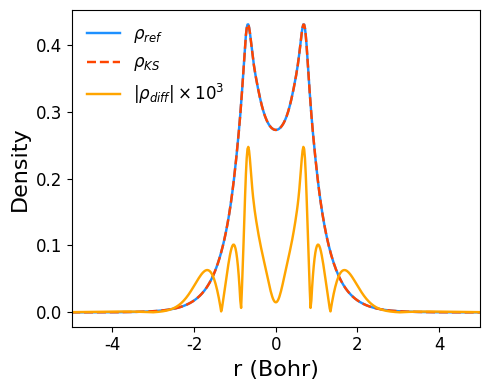

In [18]:
# Read densities from csv-files
rho_ref = pd.read_csv('rho_ref-total-final-z.csv')
rho_ks = pd.read_csv('rho_ks-total-final-z.csv')
rho_diff = pd.read_csv('rho_diff-total-final-z.csv')

plt.plot(rho_ref.z, rho_ref.value, color='dodgerblue', label=r'$\rho_{ref}$')
plt.plot(rho_ks.z, rho_ks.value, '--', color='orangered', label=r'$\rho_{KS}$')
plt.plot(rho_diff.z, abs(rho_diff.value)*1000., color='orange', label=r'$|\rho_{diff}| \times 10^3$')

plt.ylabel('Density', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=12, loc=2)
plt.tight_layout()
plt.show()

Let's inspect results of density test.

In [19]:
!grep "Density Test" h2.out

 Total Density Test       0.0008356035       1.9999999933       2.0000000040


The first number is the actual error, while the last two numbers are the number of electrons obtained by integrating the KS and target densities.

## 3. Kohn-Sham inversion for open-shell systems

A common way to perform standard or inverse KS calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for $\alpha$ and $\beta$ electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.  
Thus, in the spin-unrestricted case, the KS potentials $v_s^\alpha$ and $v_s^\beta$ for the $\alpha$ and $\beta$ spin are obtained by KS inversion:
$$v_s^\sigma = v_{ext} + v_H + v_{xc}^\sigma$$
with $\sigma = \alpha, \beta$.  
The target densities $\rho^\alpha$ and $\rho^\beta$ for $\alpha$ and $\beta$ electrons must be provided as input for KS inversion calculation.

An alternative approach is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems. In this case, the total electron density should be provided as input to KS inversion and one KS potential $v_s$ is determined:
$$v_s = v_{ext} + v_H + v_{xc}$$

---

Let's start by preparing the necessary help functions.

In [20]:
def parse_eigs(outfile):
    """Parse eigenvalues from output.

    Args:
      outfile: Path to output file.

    Returns:
      eigs: List with eigenvalues.
    """
    eigs = []
    l_parse = False
    for line in open(outfile):
        if l_parse:
            for j in line.split()[2:]:
                eigs_aux.append(float(j))
        if "KSINV eigenvalues" in line:
            l_parse = True
            eigs_aux=[]
        if len(line.split()) == 0 and l_parse:
            l_parse = False
            eigs.append(eigs_aux)

    return eigs

In [21]:
# Function to make text in bold
def bold_text(text): return "\033[1m" + text + "\033[0m"

def print_eigs(eiga, eigb, na, nb, nmax):
    """Function to print eigenvalues.
    
    Args:
      eiga: List with alpha eigenvalues.
      eigb: List with beta eigenvalues.
      na: Number of alpha occupied orbitals.
      nb: Number of beta occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    for i in range(nmax):
        ea = f"{eiga[i]:7.3f}"
        eb = f"{eigb[i]:7.3f}"
        if i+1 <= na: 
            ea = bold_text(ea)
        if i+1 <= nb:
            eb = bold_text(eb)            
        print(f"{i+1:2}   {ea}  {eb}")

### 3.1 Kohn-Sham inversion for Li atom using FCI density
Let's create a new directory and run FCI calculation that stores the target density.

In [22]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/li_from_fci", exist_ok=True)
os.chdir("Tutorials/KSINV/li_from_fci/")

In [23]:
%%writefile li_fci.in
basis={
default,aug-cc-pwCVTZ
}

symmetry,nosym
angstrom
geometry={
1

Li     0.0000000    0.0000000    0.00000000
}


hf 
{fci;dm,3000.2;core}
{matrop;export,3000.2,dm.dat,status=rewind,prec=sci}

Writing li_fci.in


In [24]:
_ = os.system(f"{MOLPRO} < li_fci.in > li_fci.out") # run calculation

In [25]:
!grep "!FCI STATE 1.1 Energy" li_fci.out

 !FCI STATE 1.1 Energy                 -7.471567086970


#### 3.1.1 Spin-unrestricted KS inversion
Now we can perform spin-unrestricted KS inversion.

In [26]:
%%writefile li_uks.in
basis={
default,aug-cc-pwCVTZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
1

Li        0.000000    0.000000    0.000000
}

hf,maxit=0

spin=1

{matrop;import,2140.2,file=dm.dat}

acfd;uksinv,maxit=100,refden=2140.2,e_ref=-7.471567086969,thr_fai_oep=5d-2,\
plot_vxc=1,plot_vref=1,plot_z=1

Writing li_uks.in


In [27]:
_ = os.system(f"{MOLPRO} < li_uks.in > li_uks.out") # run calculation

Let's parse and print resulting eigenvalues.

In [28]:
eigs = parse_eigs("li_uks.out")
print("Eigenvalues from spin-unrestricted KS inversion")
print_eigs(eigs[0], eigs[1], 2, 1, 5)

Eigenvalues from spin-unrestricted KS inversion
 1    -2.091   -2.451
 2    -0.239   -0.297
 3    -0.165   -0.232
 4    -0.165   -0.232
 5    -0.165   -0.232


The electron configuration of Li in its ground state is $1s^22s^1$. There are two occupied $\alpha$ orbitals and one occupied $\beta$ orbital. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system.  
A special feature of the spin-unrestricted KS solution for the Li atom resulting from KS inversion, discussed in detail in [J. Chem. Phys. 120, 8364–8372 (2004)](https://doi.org/10.1063/1.1698561), is that the orbital energy of the lowest unoccupied $\beta$ orbital is lower than that of the highest occupied $\alpha$ orbital. Our calculation reproduces this feature.

Finally, let's plot $\alpha$ and $\beta$ exchange-correlation potentials.

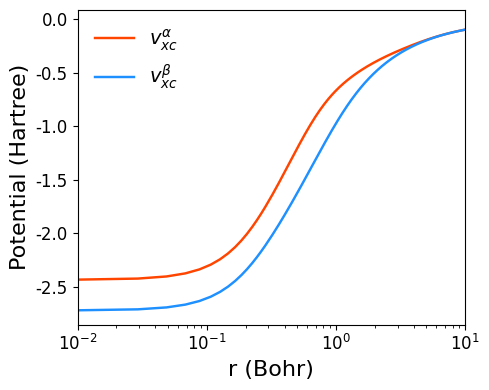

In [29]:
# Read potentials from csv-files
vrefa = pd.read_csv('vref-alpha-final-z.csv')
vxca = pd.read_csv('vxc-alpha-final-z.csv')
vrefb = pd.read_csv('vref-beta-final-z.csv')
vxcb = pd.read_csv('vxc-beta-final-z.csv')

# Plot potentials
plt.plot(vxca.z, vrefa.value+vxca.value, color='orangered', label=r'$v_{xc}^\alpha$')
plt.plot(vxcb.z, vrefb.value+vxcb.value, color='dodgerblue', label=r'$v_{xc}^\beta$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xscale("log")
plt.xlim(0.01, 10)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

#### 3.1.2 Spin-restricted KS inversion
Now we will perform the spin-restricted KS inversion for Li. Note that we have to explicitly specify the number of $\alpha$ and $\beta$ electrons, see `noa` and `nob` parameters.

In [30]:
%%writefile li_rks.in
basis={
default,aug-cc-pwCVTZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
1

Li        0.000000    0.000000    0.000000
}

hf,maxit=0

spin=1

{matrop;import,2140.2,file=dm.dat}

acfd;ksinv,maxit=100,refden=2140.2,e_ref=-7.471567086969,thr_fai_oep=5d-2,noa=2,nob=1,\
plot_vxc=1,plot_vref=1,plot_z=1

Writing li_rks.in


In [31]:
_ = os.system(f"{MOLPRO} < li_rks.in > li_rks.out") # run calculation

In [32]:
eigs = parse_eigs("li_rks.out")
print("Eigenvalues from spin-restricted KS inversion")
print_eigs(eigs[0], eigs[0], 2, 1, 5)

Eigenvalues from spin-restricted KS inversion
 1    -2.219   -2.219
 2    -0.256   -0.256
 3    -0.183   -0.183
 4    -0.183   -0.183
 5    -0.183   -0.183


In contrast to the spin-unrestricted case, the spin-restricted KS inversion does not exhibit spin symmetry breaking leading to the same orbital energies in $\alpha$ and $\beta$ spin channels.

There is only one exchange-correlation potential that we plot.

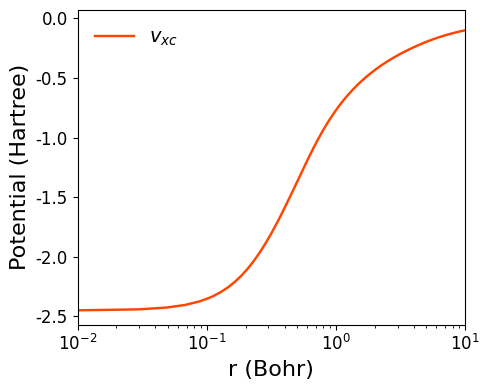

In [33]:
# Read potentials from csv-files
vref = pd.read_csv('vref-total-final-z.csv')
vxc = pd.read_csv('vxc-total-final-z.csv')

# Plot potentials
plt.plot(vxc.z, vref.value+vxc.value, color='orangered', label='$v_{xc}$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xscale("log")
plt.xlim(0.01, 10)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

#### 3.1.3 Spin-unrestricted KS inversion with fixed HOMO eigenvalues
With Gaussian basis set KS inversion, it might be difficult to obtain accurate orbital energy of highest occupied molecular orbital (HOMO). However, this orbital energy can be fixed to a known accurate value. To do this we need to enable the `homo=1` option and specify `epsilon_major` and `epsilon_minor` which are the required HOMO energies for $\alpha$ and $\beta$ spins. In the case of one set of spatial orbitals, only `epsilon_major` is used.

I will use `epsilon_major=-0.198121` and `epsilon_minor=-2.36738`. This are values from FCI total energy difference calculations using aug-cc-pwCV5Z orbital basis set. Alternatively, minus ionization potentials from experiments can be used.

In [34]:
%%writefile li_uks_homo.in
basis={
default,aug-cc-pwCVTZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
1

Li        0.000000    0.000000    0.000000
}

hf,maxit=0

spin=1

{matrop;import,2140.2,file=dm.dat}

acfd;uksinv,maxit=100,refden=2140.2,e_ref=-7.471567086969,thr_fai_oep=5d-2,\
plot_vxc=1,plot_vref=1,plot_z=1,\
homo=1,epsilon_major=-0.198121,epsilon_minor=-2.36738

Writing li_uks_homo.in


In [35]:
_ = os.system(f"{MOLPRO} < li_uks_homo.in > li_uks_homo.out") # run calculation

In [36]:
eigs = parse_eigs("li_uks_homo.out")
print("Eigenvalues from spin-unrestricted KS inversion")
print_eigs(eigs[0], eigs[1], 2, 1, 5)

Eigenvalues from spin-unrestricted KS inversion
 1    -2.066   -2.367
 2    -0.198   -0.264
 3    -0.127   -0.195
 4    -0.127   -0.195
 5    -0.127   -0.195


Now the HOMO eigenvalues are shifted to predefined values. There is a visible change in the form of the exchange-correlation potential for the $\alpha$ spin.

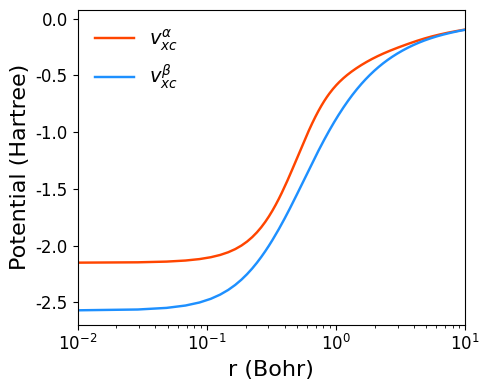

In [37]:
# Read potentials from csv-files
vrefa = pd.read_csv('vref-alpha-final-z.csv')
vxca = pd.read_csv('vxc-alpha-final-z.csv')
vrefb = pd.read_csv('vref-beta-final-z.csv')
vxcb = pd.read_csv('vxc-beta-final-z.csv')

# Plot potentials
plt.plot(vxca.z, vrefa.value+vxca.value, color='orangered', label=r'$v_{xc}^\alpha$')
plt.plot(vxcb.z, vrefb.value+vxcb.value, color='dodgerblue', label=r'$v_{xc}^\beta$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xscale("log")
plt.xlim(0.01, 10)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Kohn-Sham inversion for B atom using AQCC density, space-symmetrization
The spin-unrestricted KS method is prone to space symmetry breaking when the KS wave function fails to transform as an irreducible representation of the point group symmetry of the system under consideration. The same can happen with the spin-restricted KS method when it applied to open-shell systems.
Our KS inversion implementation allows the application of space symmetrization, which enforces the correct space symmetry of the KS wave function.


Let's start with the standard spin-unrestricted KS inversion for the B atom, for which space symmetry breaking occurs. This time we will use the AQCC target density.

<div class="alert alert-block alert-info"> <b>NOTE:</b> CCSD and CCSD(T) implementation in Molpro does not allow to store density matrix when applied to open-shell systems. Therefore, we must use CI code in this case. Examples using FCI and AQCC are provided in the tutorial. Two other options I have tested are RS2 and CISD. to store the density matrix in RS2 calculations, use: {rs2;dm,2140.2;core} and in CISD: {ci;save,density=2140.2,spinden;core}. For RS2, CISD, and AQCC, one can also use multi-reference variants which potentially are more accurate. </div>

In [38]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/b_from_aqcc", exist_ok=True)
os.chdir("Tutorials/KSINV/b_from_aqcc/")

In [39]:
%%writefile b_uks.in
basis={
default,aug-cc-pwCVQZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
1

B    0.000000    0.000000    0.000000
}

{cahf;closed,1;shell,3,2.1,3.1,4.1,5.1}

spin=1

{aqcc;save,density=2140.2,spinden;core}
e_ref=energy

acfd;uksinv,maxit=100,refden=2140.2,e_ref=e_ref,thr_fai_oep=1.7d-2

Writing b_uks.in


In [40]:
_ = os.system(f"{MOLPRO} < b_uks.in > b_uks.out") # run calculation

In [41]:
eigs = parse_eigs("b_uks.out")
print("Eigenvalues from spin-unrestricted KS inversion")
print_eigs(eigs[0], eigs[1], 3, 2, 5)

Eigenvalues from spin-unrestricted KS inversion
 1    -6.836   -7.031
 2    -0.498   -0.481
 3    -0.285   -0.290
 4    -0.278   -0.290
 5    -0.278   -0.234


First, due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. We already observed this in spin-unrestricted calculations for the Li atom.
In contrast to the Li atom, however, the energies of the orbitals in the $p$-shell in both spin channels do not exhibit a three-fold degeneracy, but split into a non-degenerate and a doubly degenerate level reflecting a cylindrical instead of spherical space symmetry. This is manifistation of space symmetry breaking.

Let's enforce correct space symmetry in spin-unrestricted inversion using `space_sym=1`.

In [42]:
%%writefile b_uks_space_sym.in
basis={
default,aug-cc-pwCVQZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
1

B    0.000000    0.000000    0.000000
}

{cahf;closed,1;shell,3,2.1,3.1,4.1,5.1}

spin=1

{aqcc;save,density=2140.2,spinden;core}
e_ref=energy

acfd;uksinv,maxit=100,refden=2140.2,e_ref=e_ref,thr_fai_oep=1.7d-2,space_sym=1

Writing b_uks_space_sym.in


In [43]:
_ = os.system(f"{MOLPRO} < b_uks_space_sym.in > b_uks_space_sym.out") # run calculation

In [44]:
eigs = parse_eigs("b_uks_space_sym.out")
print("Eigenvalues from spin-unrestricted KS inversion with space-symmetrization")
print_eigs(eigs[0], eigs[1], 3, 2, 5)

Eigenvalues from spin-unrestricted KS inversion with space-symmetrization
 1    -6.827   -7.030
 2    -0.503   -0.480
 3    -0.284   -0.271
 4    -0.284   -0.271
 5    -0.284   -0.271


As might be seen, the spherical symmetry of real electronic system is restored and the orbitals in the $p$-shell are three-fold degenerate. However, the symmetry breaking in spin space remains and the orbitals in the $\alpha$ and $\beta$ spin channels and their eigenvalues are different.

To restore full symmetry of real electronic system, we can use spin-restricted, i.e. spin-symmetrized, KS inversion and space-symmetrization.

In [45]:
%%writefile b_full_sym.in
basis={
default,aug-cc-pwCVQZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
1

B    0.000000    0.000000    0.000000
}

{cahf;closed,1;shell,3,2.1,3.1,4.1,5.1}

spin=1

{aqcc;save,density=2140.2,spinden;core}
e_ref=energy

acfd;ksinv,maxit=100,refden=2140.2,e_ref=e_ref,thr_fai_oep=1.7d-2,space_sym=1,noa=3,nob=2

Writing b_full_sym.in


In [46]:
_ = os.system(f"{MOLPRO} < b_full_sym.in > b_full_sym.out") # run calculation

In [47]:
eigs = parse_eigs("b_full_sym.out")
print("Eigenvalues from fully-symmetrized KS inversion")
print_eigs(eigs[0], eigs[0], 3, 2, 5)

Eigenvalues from fully-symmetrized KS inversion
 1    -6.888   -6.888
 2    -0.497   -0.497
 3    -0.280   -0.280
 4    -0.280   -0.280
 5    -0.280   -0.280


The full symmetry of the real electronic system is restored. The orbitals in the $p$-shell exhibit three-fold degeneracy and the same orbitals result for the two spin channels.

## 4. Plotting data on a plane
In this section I will show how to plot data on a plane. I will use the example of the H$_3$ triangle system and plot density data on a plane. Potentials can be plotted in a similar way.

In [48]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/h3", exist_ok=True)
os.chdir("Tutorials/KSINV/h3/")

In [49]:
%%writefile h3.in
basis={
default,aug-cc-pwCVTZ
set,oep
default,aug-cc-pVDZ/mp2fit
}

symmetry,nosym

angstrom
geometry={
3

H     0.0000000    0.0000000    -0.45
H     0.0000000    0.0000000     0.45
H     0.0000000    0.7794230     0.00
}

spin=1

hf 
{aqcc;save,density=2140.2,spinden;core}
e_ref=energy

acfd;uksinv,maxit=100,refden=2140.2,e_ref=e_ref,thr_fai_oep=5d-2,\
plot_rho_ref=1,plot_rho_ks=1,plot_rho_diff=1,plot_yz=1,\
plotrange=5d0,gridsize=512

Writing h3.in


In [50]:
_ = os.system(f"{MOLPRO} < h3.in > h3.out") # run calculation

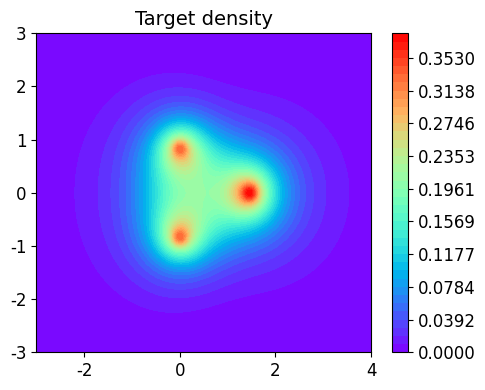

In [51]:
# read reference densities
rho_ref_a = pd.read_csv('rho_ref-alpha-final-yz.csv')
rho_ref_b = pd.read_csv('rho_ref-beta-final-yz.csv')

# prepare data
Y = np.sort(np.array(list(set(rho_ref_a.y))))
Z = np.sort(np.array(list(set(rho_ref_a.z))))
V = (rho_ref_a.value.to_numpy()+rho_ref_b.value.to_numpy()).reshape(Y.size,Z.size)

# plot
levels = np.linspace(0.0, np.amax(V) , 40) 
cs = plt.contourf(Z, Y, V, levels, cmap=plt.get_cmap('rainbow'))
plt.colorbar(cs)
plt.ylim(-3, 3)
plt.xlim(-3, 4)
plt.title("Target density", fontsize=14)
plt.tight_layout()
plt.show()

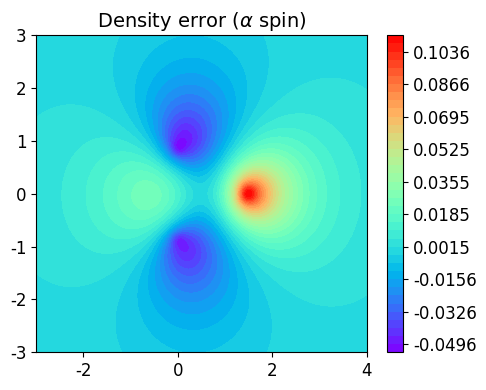

In [52]:
# read reference densities
rho_diff_a = pd.read_csv('rho_diff-alpha-final-yz.csv')

# prepare data
Y = np.sort(np.array(list(set(rho_diff_a.y))))
Z = np.sort(np.array(list(set(rho_diff_a.z))))
V = rho_diff_a.value.to_numpy().reshape(Y.size,Z.size)

# plot
levels = np.linspace(np.amin(V), np.amax(V), 40) 
cs = plt.contourf(Z, Y, V, levels, cmap=plt.get_cmap('rainbow'))
plt.colorbar(cs)
plt.ylim(-3, 3)
plt.xlim(-3, 4)
plt.title(r"Density error ($\alpha$ spin)", fontsize=14)
plt.tight_layout()
plt.show()

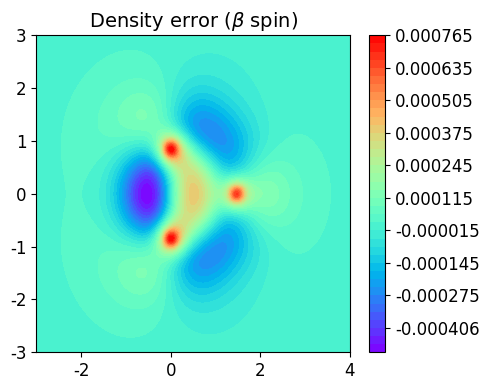

In [53]:
# read reference densities
rho_diff_a = pd.read_csv('rho_diff-beta-final-yz.csv')

# prepare data
Y = np.sort(np.array(list(set(rho_diff_a.y))))
Z = np.sort(np.array(list(set(rho_diff_a.z))))
V = rho_diff_a.value.to_numpy().reshape(Y.size,Z.size)

# plot
levels = np.linspace(np.amin(V), np.amax(V), 40) 
cs = plt.contourf(Z, Y, V, levels, cmap=plt.get_cmap('rainbow'))
plt.colorbar(cs)
plt.ylim(-3, 3)
plt.xlim(-3, 4)
plt.title(r"Density error ($\beta$ spin)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Use of density fitting

Density fitting can be used in the KS inversion, which significantly speeds up the process when the system being inverted is large. I want to demonstrate how to use it with one example. I will use density matrix calculated for H$_2$ with CCSD(T) previosly.

In [54]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/h2_from_ccsdt_2stage_with_df", exist_ok=True)
shutil.copy("Tutorials/KSINV/h2_from_ccsdt_2stage/dm.dat", "Tutorials/KSINV/h2_from_ccsdt_2stage_with_df/dm.dat")
os.chdir("Tutorials/KSINV/h2_from_ccsdt_2stage_with_df/")

We can perform the KS inversion with `gdirect` option and density fitting (`dfit=1`) as follows:

In [55]:
%%writefile h2_ksinv_with_df.in
gdirect

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit ! density fitting basis
}

symmetry,nosym ! KSINV does not use symmetry

angstrom
geometry={
2

H 0.0 0.0 0.370946
H 0.0 0.0 -0.370946
}

{matrop;read,den,type=density,file=dm.dat;save,den,1325.1} ! read stored density matrix

df-hf,maxit=0,df_basis=dfit ! HF calculation with 0 iterations
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;ksinv,refden=1325.1,e_ref=-1.173867500644,thr_fai_oep=1.7d-2,dfit=1,\ ! KSINV calculation
plot_vx=1,plot_vc=1,plot_vxc=1,plot_vref=1,plot_z=1

Writing h2_ksinv_with_df.in


<div class="alert alert-block alert-info"> <b>Important:</b> It is necessary to read and store the density matrix in a record first and only after this to run Hartree-Fock and KS inversion calculations. </div> 

In [56]:
_ = os.system(f"{MOLPRO} < h2_ksinv_with_df.in > h2_ksinv_with_df.out") # run calculation

Let's plot potentials to verify the calculation.

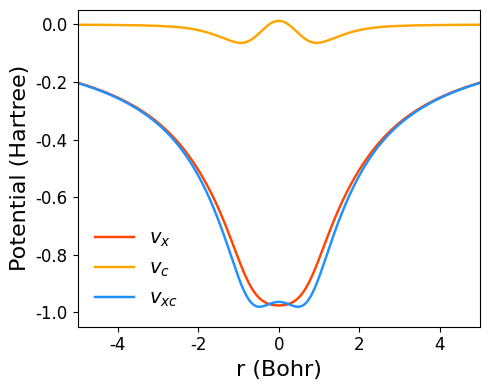

In [57]:
# Read potentials from csv-files
vref = pd.read_csv('vref-total-final-z.csv')
vx = pd.read_csv('vx-total-final-z.csv')
vc = pd.read_csv('vc-total-final-z.csv')
vxc = pd.read_csv('vxc-total-final-z.csv')

# Plot potentials
plt.plot(vx.z, vref.value+vx.value, color='orangered', label='$v_x$')
plt.plot(vc.z, vc.value, color='orange', label='$v_c$')
plt.plot(vxc.z, vref.value+vxc.value, color='dodgerblue', label='$v_{xc}$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.ylim(-1.05, 0.05)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Error measures

When energy contributions are of interest, it is essential to evaluate the error measures of the KS inversion because large errors render energy contributions meaningless. These measures are printed in the section of the output file labeled "Error Measures" and include:
- Hartree energy error
- External energy error
- Lieb error

You can read about these error measures in Ref. 6, along with strategies for reducing them. The `density_test` option can also be used to evaluate integrated density error.

I will repeat the example of the CO molecule from Ref. 6, for which the external energy error and the Lieb error are significantly reduced by addition of two additional tight basis functions to the auxiliary OEP basis. We will use the density matrix calculated with the aug-cc-pwCV5Z orbital basis set and stored in the `co_ccsdt` directory.

In [58]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/co_std", exist_ok=True)
shutil.copy("co_ccsdt/dm.dat", "Tutorials/KSINV/co_std/dm.dat")
os.chdir("Tutorials/KSINV/co_std")

In [59]:
%%writefile co_std.in
gdirect

basis={
default,aug-cc-pwCV5Z
set,dfit;default,aug-cc-pwCV5Z/mp2fit
set,oep
default,C=aug-cc-pVDZ/mp2fit;O=aug-cc-pVDZ/mp2fit
}

symmetry,nosym
angstrom
geometry={
2

C 0.0 0.0 -0.646514
O 0.0 0.0 0.484886
}

charge=0
spin=0

{matrop;read,den,type=density,file=dm.dat;save,den,1325.1}

df-hf,maxit=0,df_basis=dfit
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;ksinv,dfit=1,maxit=100,refden=1325.1,e_ref=-113.316320697718,thr_fai_oep=5d-3,\ 
plot_z=1,plot_vxc=1,plot_vref=1,plot_rho_ks=1,plot_rho_ref=1,gridsize=12000,plotrange=7.

Writing co_std.in


In [60]:
_ = os.system(f"{MOLPRO} < co_std.in > co_std.out") # run calculation

In [61]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/KSINV/co_aug", exist_ok=True)
shutil.copy("co_ccsdt/dm.dat", "Tutorials/KSINV/co_aug/dm.dat")
os.chdir("Tutorials/KSINV/co_aug")

In [62]:
%%writefile co_aug.in
gdirect

basis={
default,aug-cc-pwCV5Z
set,dfit;default,aug-cc-pwCV5Z/mp2fit
set,oep
default,C=aug-cc-pVDZ/mp2fit;O=aug-cc-pVDZ/mp2fit
s,c,180.
s,o,300.
}

symmetry,nosym
angstrom
geometry={
2

C 0.0 0.0 -0.646514
O 0.0 0.0 0.484886
}

charge=0
spin=0

{matrop;read,den,type=density,file=dm.dat;save,den,1325.1}

df-hf,maxit=0,df_basis=dfit ! HF calculation with 0 iterations
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;ksinv,dfit=1,maxit=100,refden=1325.1,e_ref=-113.316320697718,thr_fai_oep=5d-3,\ 
plot_z=1,plot_vxc=1,plot_vref=1,plot_rho_ks=1,plot_rho_ref=1,gridsize=12000,plotrange=7.

Writing co_aug.in


In [63]:
_ = os.system(f"{MOLPRO} < co_aug.in > co_aug.out") # run calculation

In [64]:
os.chdir(NOTEBOOK_DIR)

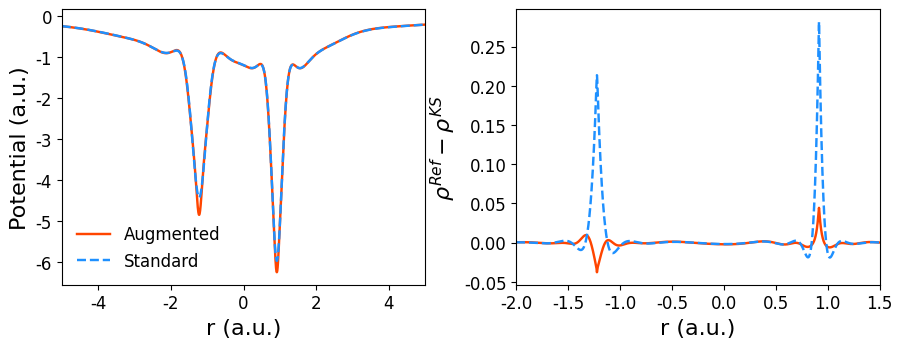

In [65]:
fig, axs = plt.subplots(1, 2, figsize=(9,3.5))
plt.tight_layout()
plt.subplots_adjust(wspace=0.25, bottom=0.15, left=0.06)

vref = pd.read_csv('Tutorials/KSINV/co_aug/vref-total-final-z.csv')
vxc = pd.read_csv('Tutorials/KSINV/co_aug/vxc-total-final-z.csv')
axs[0].plot(vxc.z, vref.value+vxc.value, color='orangered', label='Augmented')

vref = pd.read_csv('Tutorials/KSINV/co_std/vref-total-final-z.csv')
vxc = pd.read_csv('Tutorials/KSINV/co_std/vxc-total-final-z.csv')
axs[0].plot(vxc.z, vref.value+vxc.value, "--", color='dodgerblue', label='Standard')

axs[0].set_ylabel('Potential (a.u.)', fontsize=16)
axs[0].set_xlabel('r (a.u.)', fontsize=16)
axs[0].set_xlim(-5, 5)
axs[0].legend(frameon=False, fontsize=12)

rho_ref = pd.read_csv('Tutorials/KSINV/co_aug/rho_ref-total-final-z.csv')
rho_ks = pd.read_csv('Tutorials/KSINV/co_aug/rho_ks-total-final-z.csv')
axs[1].plot(rho_ref.z, rho_ref.value-rho_ks.value, color='orangered', label='Augmented')

rho_ref = pd.read_csv('Tutorials/KSINV/co_std/rho_ref-total-final-z.csv')
rho_ks = pd.read_csv('Tutorials/KSINV/co_std/rho_ks-total-final-z.csv')
axs[1].plot(rho_ref.z, rho_ref.value-rho_ks.value, "--", color='dodgerblue', label='Standard')

axs[1].set_ylabel(r'$\rho^{Ref}-\rho^{KS}$', fontsize=16)
axs[1].set_xlabel('r (a.u.)', fontsize=16)
axs[1].set_xlim(-2, 1.5)

plt.show()

In [66]:
!grep "KSINV Hartree energy error" Tutorials/KSINV/co_std/co_std.out
!grep "KSINV External energy error" Tutorials/KSINV/co_std/co_std.out
!grep "KSINV Lieb error" Tutorials/KSINV/co_std/co_std.out

  KSINV Hartree energy error            0.001733746045
  KSINV External energy error          -0.020013165890
  KSINV Lieb error                      0.018400615971


In [67]:
!grep "KSINV Hartree energy error" Tutorials/KSINV/co_aug/co_aug.out
!grep "KSINV External energy error" Tutorials/KSINV/co_aug/co_aug.out
!grep "KSINV Lieb error" Tutorials/KSINV/co_aug/co_aug.out

  KSINV Hartree energy error            0.001350442433
  KSINV External energy error          -0.001121477438
  KSINV Lieb error                     -0.000132949441


## 7. Concluding remarks
In this tutorial, we explored KS inversion calculations using Molpro. We considered the inversion for closed- and open-shell systems.

For open-shell systems, in addition to the standard spin-unrestricted inversion, we looked at the spin-restricted inversion, which preserves the correct spin symmetry of a real electronic system. For both spin-unrestricted and spin-restricted KS inversions for open-shell systems, we also performed calculations with additional space-symmetrization, which forces the KS system to have the correct spatial symmetry of a real electronic system.

We considered an option to fix the orbital energy of the HOMO (or the orbital energies of the HOMOs for $\alpha$ and $\beta$ spins) to a predetermined value, which can be from experiment or from accurate total energy difference calculation of the ionization potential.

As a post-processing of calculations, we accessed and printed orbital energies resulting from KS inversion and explored how to plot the resulting potentials and densities in the form of line and plane plots. In addition, we looked at the option to enable the density test, which determines how close the resulting KS density is to the target density.

Finally, we briefly discussed the energy error measures of KS inversion and the use of density fitting.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/Molpro_Tutorials/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/Molpro_Tutorials/)  If you found this tutorial helpful, consider ⭐-ing the repository.